In [2]:
# Prepare detection rate data
import geopandas as gpd
import pandas as pd
import ee
import os
import geemap
import json
from sqlalchemy import create_engine
from dotenv import load_dotenv
from shapely.geometry import shape

load_dotenv(dotenv_path="./.env")

ee.Initialize()

DB_PASSWORD = os.environ.get('DB_PASSWORD')
DB_IP = os.environ.get('DB_IP')
engine = create_engine(f"mysql+mysqlconnector://root:{DB_PASSWORD}@{DB_IP}:3306/mai-database")

# Import candidate locations from Earth Engine
model_path = "/Users/pauldingus/Documents/MAI/mai_cnn/models/ConvNeXt_transfer/20250520_1230"
country_name = 'Ethiopia'
predictions = pd.read_csv(f'{model_path}/all_predictions_{country_name}.csv')
predictions = gpd.GeoDataFrame(predictions, geometry=gpd.GeoSeries.from_wkt(predictions['geometry'])).set_crs("EPSG:4326")
candidate_locs = ee.FeatureCollection(f'projects/planetupload/assets/cleanedLocs/{country_name}/{country_name}')
candidate_locs_gdf = geemap.ee_to_gdf(candidate_locs)

# Get maxSignal and market information from the database
query = f"""
    SELECT
        lf.Location,
        lf.maxSignal,
        lf.market,
        lf.false_positive,
        lf.source,
        pr.minStrictnessRank,
        pr.runAnyway
    FROM
        location_file lf
    JOIN
        process_runs pr ON lf.Location = pr.Location
    WHERE lf.country="{country_name}"
        AND pr.Setup="MpM6"
        AND NOT minStrictnessRank IS NULL
    LIMIT 10000
"""
db_info = pd.read_sql(query, con=engine)

# Replace NaN with 0 in market and false_positive columns
db_info['market'] = db_info['market'].fillna(0)
db_info['false_positive'] = db_info['false_positive'].fillna(0)

# If runAnyways = yes, set market to 1
db_info.loc[db_info['runAnyway'] == 'yes', 'market'] = 1

# If false_positive = 1, set market to 0
db_info.loc[db_info['false_positive'] == 1, 'market'] = 0

# If minStrictnessRank < 21 and false_positive = 0 and runAnyways != 'yes', set market to 1
db_info.loc[(db_info['minStrictnessRank'] < 21) & (db_info['false_positive'] == 0) & (db_info['runAnyway'] != 'yes'), 'market'] = 1

# Merge candidate_locs_gdf and db_info on mktID (from candidate_locs_gdf) and Location (from db_info)
candidate_locs_gdf = candidate_locs_gdf.merge(db_info, left_on='mktID', right_on='Location', how='inner', suffixes=('', '_db'))

def get_max_prediction_overlap(geom):
    overlapping = predictions[predictions.geometry.intersects(geom)]
    if not overlapping.empty:
        return overlapping['prediction'].max()
    else:
        return 0

def get_mean_prediction_overlap(geom):
    centroid = geom.centroid
    overlapping = predictions[predictions.geometry.intersects(centroid)]
    pred_values = list(overlapping['prediction'].values)
    if len(pred_values) > 1:
        return sum(pred_values) / len(pred_values)
    elif len(pred_values) == 1:
        return sum(pred_values) / 2
    else:
        return 0

# Calculate max and mean predictions for each candidate location
candidate_locs_gdf['max_prediction'] = candidate_locs_gdf['geometry'].apply(get_max_prediction_overlap)    
candidate_locs_gdf['mean_prediction'] = candidate_locs_gdf['geometry'].apply(get_mean_prediction_overlap)

candidate_locs_s2 = ee.FeatureCollection('projects/ethiopia-candidate-locs/assets/allLocs_v20240812')
def set_mktID(f):
    coor = f.centroid(1).geometry().coordinates()
    lat = ee.String("lat").cat(ee.Number(coor.get(1)).multiply(10000).round().divide(10000).format())
    lon = ee.String("lon").cat(ee.Number(coor.get(0)).multiply(10000).round().divide(10000).format())
    mktIDstring = lon.cat(lat).replace('\\.', '_', 'g')
    return f.set({'mktID': mktIDstring, 'centroid': f.geometry().centroid()})

candidate_locs_s2 = candidate_locs_s2.map(set_mktID)

candidate_locs_s2_gdf = geemap.ee_to_gdf(candidate_locs_s2)

# Mark source column as "S2" in candidate_locs_gdf if Location in mktID column of candidate_locs_s2_gdf
candidate_locs_gdf.loc[
    candidate_locs_gdf['Location'].isin(candidate_locs_s2_gdf['mktID']),
    'source'
] = 'S2'

# Mark source as "hand-drawn" if source is NaN
candidate_locs_gdf['source'] = candidate_locs_gdf['source'].fillna('hand drawn')

/Users/pauldingus/Documents/MAI/mai_cnn/.venv/lib/python3.8/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


/var/folders/p2/p5d8wlsx6_ggsqbfcdsnn6880000gn/T/ipykernel_6164/750297329.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


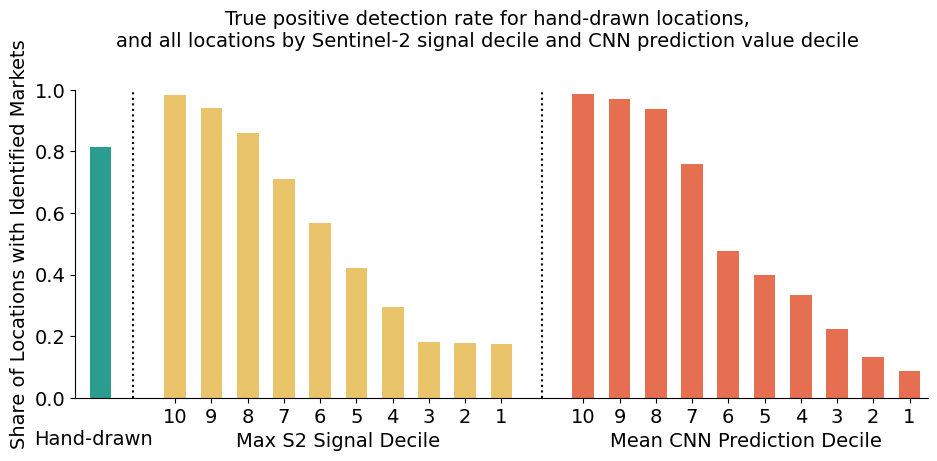

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

maincolors = ['#2A9D8F','#E9C46A','#E76F51']
fontsize = 14

# Create consistent x positions
x_positions = np.arange(1, 11)

# Hand drawn: place value at position 5 (center), rest are np.nan
hand_drawn_vals = [np.nan]*10
hand_drawn_vals[4] = 0.77  # Place the TPR at the 5th decile position

# Dummy data, replace with your own
df_plot = candidate_locs_gdf[['maxSignal_db', 'mean_prediction', 'market', 'source']].dropna()
df_plot['mean_prediction_jitter'] = (df_plot['mean_prediction'] + np.random.uniform(-1e-8, 1e-8, len(df_plot)))

# True positive rate for hand drawn locations
hand_drawn = df_plot[df_plot['source'] == 'hand drawn'].groupby('source').agg({'market': 'mean'}).rename(columns={'market': 'tpr'})

# True positive rate per decile of maxSignal_db
df_plot['maxSignal_decile'] = pd.qcut(df_plot['maxSignal_db'], 10, labels=False, duplicates='drop')
tpr_maxSignal = df_plot.groupby('maxSignal_decile').agg({'market': 'mean'}).rename(columns={'market': 'tpr'})
tpr_maxSignal.index = tpr_maxSignal.index.astype(int) + 1

# True positive rate per decile of mean_prediction
df_plot['prediction_decile'] = pd.qcut(df_plot['mean_prediction_jitter'], 10, labels=False, duplicates='drop')
tpr_prediction = df_plot.groupby('prediction_decile').agg({'market': 'mean'}).rename(columns={'market': 'tpr'})
tpr_prediction.index = tpr_prediction.index.astype(int) + 1

data = [hand_drawn, tpr_maxSignal, tpr_prediction]

fig = plt.figure(figsize=(11, 4))
gs = GridSpec(1, 3, width_ratios=[0.15, 1.5, 1.5], wspace=0.18)
fig.suptitle('True positive detection rate for hand-drawn locations,\nand all locations by Sentinel-2 signal decile and CNN prediction value decile', fontsize=fontsize, y=1.08)


axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
ymax = 1

for p, ax in enumerate(axes):
    df = data[p]
    if p == 0:
        ax.bar(0, df['tpr'].iloc[0], color=maincolors[0], width=0.42)
        ax.set_xlim(-0.4, 0.07)  # Adjust limits so the width shows visually
        ax.set_xticks([])
        ax.set_xlabel('Hand-drawn', fontsize=fontsize, labelpad=23)
    else:
        # Plot in descending decile order
        df_desc = df.iloc[::-1]
        ax.bar(df_desc.index, df_desc['tpr'], color=maincolors[p], width=0.6)
        ax.set_xticks(df_desc.index)
        ax.set_xticklabels(df_desc.index.tolist(), fontsize=fontsize)
        ax.set_xlim(10.5, 0.5)  # This REVERSES the x-axis
    ax.set_ylim(0, ymax)
    if p == 0:
        ax.set_ylabel('Share of Locations with Identified Markets', fontsize=fontsize)
        ax.tick_params(axis='y', labelsize=fontsize)
    else:
        ax.tick_params(axis='y', left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

# Set x axis label for second and third axes
axes[1].set_xlabel('Max S2 Signal Decile', fontsize=fontsize)
axes[2].set_xlabel('Mean CNN Prediction Decile', fontsize=fontsize)

# Draw bridging x-axis at y=0 across all three axes
y_fraction = axes[0].get_position().y0
x_start = axes[0].get_position().x0
x_end = axes[-1].get_position().x1
fig.lines.append(plt.Line2D(
    [x_start, x_end], [y_fraction, y_fraction],
    transform=fig.transFigure, color='k', linewidth=0.8, zorder=10)
)

# y coordinates in figure fraction for the dividing lines (usually match the axes' vertical extent)
y0 = axes[0].get_position().y0
y1 = axes[0].get_position().y1

# x positions for dividers: right edge of ax0, right edge of ax1
nudge_amount = 0.02  # Nudge to avoid overlap with the axes
x_dividers = [axes[0].get_position().x1+nudge_amount, axes[1].get_position().x1+nudge_amount]

for x in x_dividers:
    fig.lines.append(plt.Line2D(
        [x, x], [y0, y1],
        transform=fig.transFigure,
        color='k', linestyle=':', linewidth=1.5, zorder=10
    ))

plt.tight_layout()
plt.show()
plt.close(fig)


# Add green hand-drawn performance and red generated performance as a dodged bar chart in axis 2
# Add count of locations in each decile as text
# Move the all-locations bar to axis 3


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

maincolors = ['#2A9D8F','#E9C46A','#E76F51']
fontsize = 14

# Create consistent x positions
x_positions = np.arange(1, 11)

# Hand drawn: place value at position 5 (center), rest are np.nan
hand_drawn_vals = [np.nan]*10
hand_drawn_vals[4] = 0.77  # Place the TPR at the 5th decile position

df_plot = candidate_locs_gdf[['maxSignal_db', 'mean_prediction', 'market', 'source']].dropna()
df_plot['mean_prediction_jitter'] = (df_plot['mean_prediction'] + np.random.uniform(-1e-8, 1e-8, len(df_plot)))

# True positive rate for hand drawn locations
hand_drawn = df_plot[df_plot['source'] == 'hand drawn'].groupby('source').agg({'market': 'mean'}).rename(columns={'market': 'tpr'})

# True positive rate across all locations


# True positive rate per decile of maxSignal_db
df_plot['maxSignal_decile'] = pd.qcut(df_plot['maxSignal_db'], 10, labels=False, duplicates='drop')
tpr_maxSignal = df_plot.groupby('maxSignal_decile').agg({'market': 'mean'}).rename(columns={'market': 'tpr'})
tpr_maxSignal_handDrawn = df_plot[df_plot['source'] == 'hand drawn'].groupby('maxSignal_decile').agg({'market': 'mean'}).rename(columns={'market': 'tpr'})
tpr_maxSignal = tpr_maxSignal.merge(tpr_maxSignal_handDrawn, left_index=True, right_index=True, suffixes=('', '_handDrawn'))
tpr_maxSignal.index = tpr_maxSignal.index.astype(int) + 1

# True positive rate per decile of mean_prediction
df_plot['prediction_decile'] = pd.qcut(df_plot['mean_prediction_jitter'], 10, labels=False, duplicates='drop')
tpr_prediction = df_plot.groupby('prediction_decile').agg({'market': 'mean'}).rename(columns={'market': 'tpr'})
tpr_prediction_handDrawn = df_plot[df_plot['source'] == 'hand drawn'].groupby('prediction_decile').agg({'market': 'mean'}).rename(columns={'market': 'tpr'})
tpr_prediction = tpr_prediction.merge(tpr_prediction_handDrawn, left_index=True, right_index=True, suffixes=('', '_handDrawn'))
tpr_prediction.index = tpr_prediction.index.astype(int) + 1

data = [tpr_maxSignal, tpr_prediction, hand_drawn]

tpr_maxSignal

,tpr,tpr_handDrawn
maxSignal_decile,,
1,0.172840,0.341270
2,0.176471,0.653061
3,0.181538,0.656250
4,0.295031,0.617021
5,0.419753,0.742857
6,0.566563,0.890411
7,0.708978,0.920792
8,0.861111,0.974790
9,0.941176,0.984252


/var/folders/p2/p5d8wlsx6_ggsqbfcdsnn6880000gn/T/ipykernel_95012/238041216.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


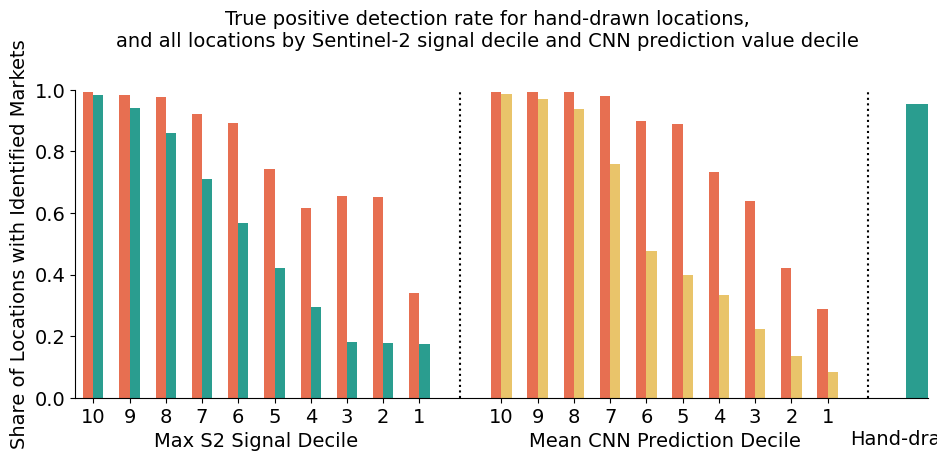

In [15]:


fig = plt.figure(figsize=(11, 4))
gs = GridSpec(1, 3, width_ratios=[1.5, 1.5, 0.15], wspace=0.18)
fig.suptitle('True positive detection rate for hand-drawn locations,\nand all locations by Sentinel-2 signal decile and CNN prediction value decile', fontsize=fontsize, y=1.08)


axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
ymax = 1

for p, ax in enumerate(axes):
    df = data[p]
    if p == 2:
        ax.bar(0, df['tpr'].iloc[0], color=maincolors[0], width=0.42)
        ax.set_xlim(-0.4, 0.07)  # Adjust limits so the width shows visually
        ax.set_xticks([])
        ax.set_xlabel('Hand-drawn', fontsize=fontsize, labelpad=23)
    else:
        # Plot in descending decile order, as dodged bars for all vs hand-drawn
        df_desc = df.iloc[::-1]
        bar_width = 0.28
        # Plot all locations
        ax.bar(df_desc.index - bar_width/2, df_desc['tpr'], color=maincolors[p], width=bar_width, label='All')
        # Plot hand-drawn locations
        ax.bar(df_desc.index + bar_width/2, df_desc['tpr_handDrawn'], color=maincolors[2], width=bar_width, label='Hand-drawn')
        ax.set_xticks(df_desc.index)
        ax.set_xticklabels(df_desc.index.tolist(), fontsize=fontsize)
        ax.set_xlim(10.5, 0.5)  # This REVERSES the x-axis
        # if p == 1:
        #     ax.legend(fontsize=fontsize-2, loc='upper left')
        ax.set_ylim(0, ymax)
    if p == 0:
        ax.set_ylabel('Share of Locations with Identified Markets', fontsize=fontsize)
        ax.tick_params(axis='y', labelsize=fontsize)
    else:
        ax.tick_params(axis='y', left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

# Set x axis label for second and third axes
axes[0].set_xlabel('Max S2 Signal Decile', fontsize=fontsize)
axes[1].set_xlabel('Mean CNN Prediction Decile', fontsize=fontsize)

# Draw bridging x-axis at y=0 across all three axes
y_fraction = axes[0].get_position().y0
x_start = axes[0].get_position().x0
x_end = axes[-1].get_position().x1
fig.lines.append(plt.Line2D(
    [x_start, x_end], [y_fraction, y_fraction],
    transform=fig.transFigure, color='k', linewidth=0.8, zorder=10)
)

# y coordinates in figure fraction for the dividing lines (usually match the axes' vertical extent)
y0 = axes[0].get_position().y0
y1 = axes[0].get_position().y1

# x positions for dividers: right edge of ax0, right edge of ax1
nudge_amount = 0.02  # Nudge to avoid overlap with the axes
x_dividers = [axes[0].get_position().x1+nudge_amount, axes[1].get_position().x1+nudge_amount]

for x in x_dividers:
    fig.lines.append(plt.Line2D(
        [x, x], [y0, y1],
        transform=fig.transFigure,
        color='k', linestyle=':', linewidth=1.5, zorder=10
    ))

plt.tight_layout()
plt.show()
plt.close(fig)


# Add green hand-drawn performance and red generated performance as a dodged bar chart in axis 2
# Add count of locations in each decile as text
# Move the all-locations bar to axis 3
